Dataset

In [15]:
import torch
import torchvision
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

val_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

In [16]:

# define batches
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
val_loader= torch.utils.data.DataLoader(dataset=val_dataset,batch_size=64,shuffle= False)

Conversion to NUMPY

In [17]:

for images, labels in train_loader:

    images = images.cpu()
    labels = labels.cpu()

    images_np = images.numpy()
    labels_np = labels.numpy()

In [18]:
def one_hot(labels, num_classes=10):
    return np.eye(num_classes)[labels]

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

def softmax(z):
    # Numerical stability: subtract max to prevent overflow
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    eps = 1e-8
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + eps)) / m

Neural Network Class

In [19]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activation="relu", lr=0.01):
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.activation_name = activation
        self.weights = []
        self.biases = []

        # Initialize
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    def activation(self, z):
        if self.activation_name == "relu": return relu(z)
        elif self.activation_name == "sigmoid": return sigmoid(z)
        elif self.activation_name == "tanh": return tanh(z)

    def activation_derivative(self, z):
        if self.activation_name == "relu": return relu_derivative(z)
        elif self.activation_name == "sigmoid": return sigmoid_derivative(z)
        elif self.activation_name == "tanh": return tanh_derivative(z)

    def forward(self, X):
        self.a = [X]
        self.z = []

        for i in range(len(self.weights) - 1):
            z = self.a[-1] @ self.weights[i] + self.biases[i]
            self.z.append(z)
            self.a.append(self.activation(z))

        z_out = self.a[-1] @ self.weights[-1] + self.biases[-1]
        self.z.append(z_out)
        self.a.append(softmax(z_out))
        return self.a[-1]

    def backward(self, y_true):
        m = y_true.shape[0]
        grads_w = []
        grads_b = []

        delta = self.a[-1] - y_true

        for i in reversed(range(len(self.weights))):
            dw = (self.a[i].T @ delta) / m
            db = np.mean(delta, axis=0, keepdims=True)

            grads_w.insert(0, dw)
            grads_b.insert(0, db)

            if i != 0:
                delta = (delta @ self.weights[i].T) * self.activation_derivative(self.z[i-1])

        self.grads_w = grads_w
        self.grads_b = grads_b

    def update_parameters(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * self.grads_w[i]
            self.biases[i] -= self.lr * self.grads_b[i]

    def evaluate(self, loader):
        correct, total = 0, 0
        losses = []
        for images, labels in loader:
            images = images.cpu().numpy().reshape(images.shape[0], -1)
            y_true = one_hot(labels.cpu().numpy())

            y_pred = self.forward(images)
            losses.append(cross_entropy_loss(y_pred, y_true))

            preds = np.argmax(y_pred, axis=1)
            correct += np.sum(preds == labels.cpu().numpy())
            total += labels.shape[0]
        return np.mean(losses), correct / total

Training and Experiment

In [13]:
def train(model, epochs):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        for images, labels in train_loader:
            images = images.cpu().numpy().reshape(images.shape[0], -1) / 1.0
            y_true = one_hot(labels.cpu().numpy())

            model.forward(images)
            model.backward(y_true)
            model.update_parameters()

        t_loss, t_acc = model.evaluate(train_loader)
        v_loss, v_acc = model.evaluate(val_loader)

        train_losses.append(t_loss); val_losses.append(v_loss)
        train_accs.append(t_acc); val_accs.append(v_acc)

        print(f"Epoch {epoch+1}: Train Acc={t_acc:.4f}, Val Acc={v_acc:.4f}")
    return train_losses, val_losses, train_accs, val_accs

model = NeuralNetwork(layer_sizes=[784, 128, 64, 10], activation="relu", lr=0.01)
t_loss, v_loss, t_acc, v_acc = train(model, epochs=10)

Epoch 1: Train Acc=0.1124, Val Acc=0.1135
Epoch 2: Train Acc=0.1124, Val Acc=0.1135
Epoch 3: Train Acc=0.2077, Val Acc=0.2086
Epoch 4: Train Acc=0.4119, Val Acc=0.4098
Epoch 5: Train Acc=0.6811, Val Acc=0.6851
Epoch 6: Train Acc=0.7948, Val Acc=0.8028
Epoch 7: Train Acc=0.8264, Val Acc=0.8312
Epoch 8: Train Acc=0.8521, Val Acc=0.8516
Epoch 9: Train Acc=0.8712, Val Acc=0.8740
Epoch 10: Train Acc=0.8862, Val Acc=0.8880


Plot

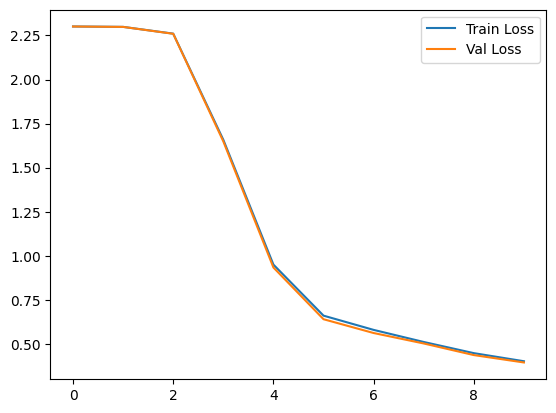

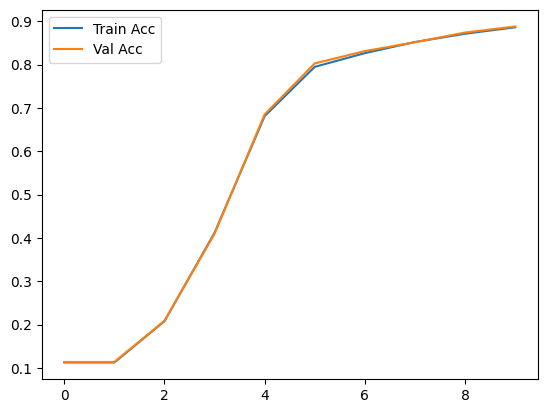

In [14]:
plt.plot(t_loss, label="Train Loss"); plt.plot(v_loss, label="Val Loss")
plt.legend(); plt.savefig("loss_curve.png"); plt.show()

plt.plot(t_acc, label="Train Acc"); plt.plot(v_acc, label="Val Acc")
plt.legend(); plt.savefig("accuracy_curve.png"); plt.show()